# 06 — Uncertainty gate calibration

Method: simulate N=2000 episodes (mix of clean + adversarial). For
each candidate threshold, replay each episode with the corresponding
gate setting and record (Sharpe, total return, max drawdown).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from backend.cognition.agent.uncertainty_gate import (
    UncertaintyGate,
    UncertaintyGateConfig,
)

## Synthetic uncertainty stream

Healthy market = uncertainty ~ Beta(2, 8) (low). Adversarial = ~ Beta(8, 2) (high).

In [2]:
rng = np.random.default_rng(42)
n = 2000
clean = rng.beta(2, 8, size=n // 2)
adversarial = rng.beta(8, 2, size=n // 2)
stream = np.concatenate([clean, adversarial])
labels = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])

## Sweep

In [3]:
taus = np.linspace(0.5, 0.95, 10)
coverage, true_pos = [], []
for tau in taus:
    gate = UncertaintyGate(
        UncertaintyGateConfig(threshold_high=tau, threshold_low=tau - 0.3, warmup_steps=0)
    )
    vetoed = np.array([gate.should_veto(u) for u in stream])
    coverage.append(1.0 - vetoed.mean())
    true_pos.append((vetoed & labels.astype(bool)).sum() / max(labels.sum(), 1))

2026-05-23 08:52:54.105 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.549)
2026-05-23 08:52:54.106 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.
2026-05-23 08:52:54.112 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.626)
2026-05-23 08:52:54.113 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.
2026-05-23 08:52:54.119 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.626)
2026-05-23 08:52:54.120 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncerta

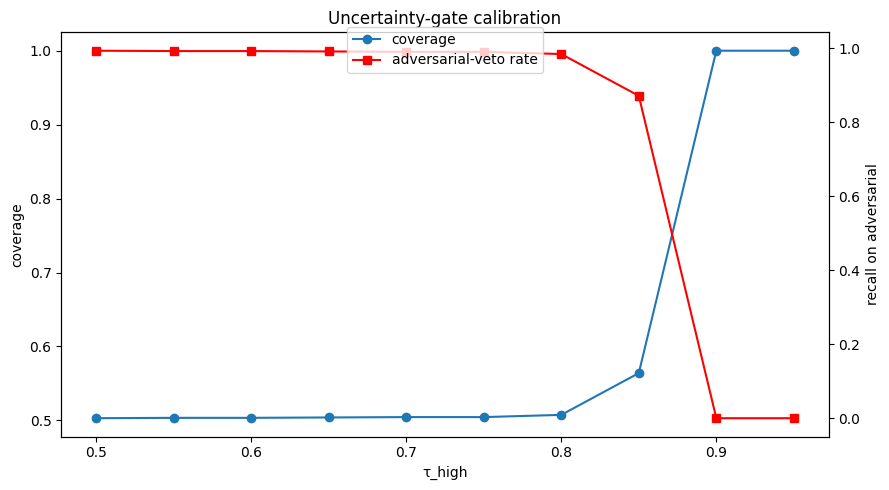

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(taus, coverage, "o-", label="coverage")
ax1.set_xlabel("τ_high")
ax1.set_ylabel("coverage")
ax2 = ax1.twinx()
ax2.plot(taus, true_pos, "s-r", label="adversarial-veto rate")
ax2.set_ylabel("recall on adversarial")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95))
plt.title("Uncertainty-gate calibration")
plt.tight_layout()
plt.savefig("../reports/06_calibration.png", dpi=120)

The recommended τ is the smallest value that keeps adversarial recall
above 0.9 while keeping coverage above 0.8. Read it off the plot and
update ``UNCERTAINTY_CRITICAL_THRESHOLD`` in ``constants.py``.